# Copymint Baseline — Logistic Regression on Hash Distances + DINOv2

**Goal:** fuse the six normalized hash distances (`aHash`, `pHash`, `dHash`, `HSVHash`, `rHash`, `cHash`) **plus a seventh learned-embedding feature (`dinov2_dist`)** into a single duplicate-probability score using binary logistic regression.

**Pipeline:**
1. Load the pair-level dataset (`label=1` → derivative copy / matching pair, `label=0` → different image)
2. **Stratified 80/20 train–test split** (stratified on `label` so both splits keep the same positive rate)
3. Train on the 80% split, evaluate on the held-out 20% with **ROC-AUC** (primary), **PR-AUC**, **F1**, and **Recall @ 95% Precision** — never raw accuracy on imbalanced data
4. **Ablation (§4b): 6 hashes vs. 6 hashes + `dinov2_dist` vs. `dinov2_dist` alone** — same split, same pipeline, so the delta is attributable to the new feature alone
5. Inspect coefficients, error-analysis by transformation type, and pick an operating threshold
6. Refit on the full dataset and serialize the model for the minting gate

> **Dataset:** `combined_training_data_with_dinov2.csv` — the DISC21-derived set (~2.2k pairs) with the DINOv2 column appended by `combine/add_dinov2_distance.py`. Positives combine (a) synthetic augmentations of a few seed images (`cropped_*`, `blur_*`, `grayscale`, …) and (b) real DISC21 query↔reference matching pairs (`disc21`). Negatives are `cross_image` and `disc21_neg` pairs.
>
> **The seventh feature:** `dinov2_dist = 1 - cos_sim` between the two L2-normalized DINOv2 CLS embeddings, produced by the *same* `retriever.embedder.ImageEmbedder` class the live retriever uses, so the training feature matches the serving feature. Same orientation as the hash columns (0 = identical, larger = more different) but a **wider range, [0, 2]** — see §1. It exists because the hashes collapse on DISC21's semantic edits (overlays, crops, re-renders), which is exactly where a learned embedding still separates.
>
> ⚠️ **Negative-set caveat:** 1028 of the 1029 `disc21_neg` rows pair queries against a single reference image (`R038409`). With a random split this leaks across train/test, so the model partly learns "distance-from-R038409" rather than a general non-match boundary. **This bites the DINOv2 feature harder than the hashes** — an embedding can encode "not this one specific photo" much more sharply than a 64-bit hash can. Treat every headline number below, and especially the §4b lift, as optimistic until the negative pool is diversified across many references.

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
TEST_SIZE = 0.20

# The six perceptual-hash distances, kept as their own list so section 4b can refit
# a hashes-only model on the identical split and measure what the 7th feature adds.
HASH_FEATURES = ["ahash_dist", "phash_dist", "dhash_dist",
                 "hsvhash_dist", "rhash_dist", "chash_dist"]

# 7th feature: DINOv2 cosine distance, 1 - cos_sim over L2-normalized CLS embeddings.
EMBED_FEATURE = "dinov2_dist"

FEATURES = HASH_FEATURES + [EMBED_FEATURE]   # feature order used everywhere below

CSV_NAME = "combined_training_data_with_dinov2.csv"

# Runs in Colab (CSV in Drive) or locally from hashing/ or hashing/combine/.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CANDIDATES = [f"/content/drive/MyDrive/{CSV_NAME}"]
except ImportError:
    CANDIDATES = [
        os.path.join("..", "benchmark_results", CSV_NAME),   # from hashing/combine/
        os.path.join("benchmark_results", CSV_NAME),         # from hashing/
    ]

CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert CSV_PATH, f"{CSV_NAME} not found. Looked in: {CANDIDATES}"
print(f"Using CSV_PATH = {CSV_PATH}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using CSV_PATH = /content/drive/MyDrive/combined_training_data_with_dinov2.csv
Features (7): ['ahash_dist', 'phash_dist', 'dhash_dist', 'hsvhash_dist', 'rhash_dist', 'chash_dist', 'dinov2_dist']


## 1. Load & inspect the data

The six hash distances are **normalized by bit-length** (Hamming distance / number of bits), so they sit on a comparable [0, 1] scale across algorithms of different lengths.

`dinov2_dist` is **not** on that scale — it is `1 - cos_sim` over unit vectors, so its range is **[0, 2]** (values above 1 mean the embeddings point away from each other). That is fine here because every model is wrapped in a `StandardScaler`, which z-scores each column before the logistic regression sees it; the coefficients in §6 are therefore still directly comparable. It matters if you ever feed features to a model *without* the scaler, or confuse this column with the FAISS `ann_distance` in the backend, which is **squared L2** over unit vectors (`2*(1 - cos_sim)`, range [0, 4]) — a different number.

`add_dinov2_distance.py` writes an **empty** `dinov2_dist` when an image could not be read, rather than silently writing 0, so blanks are genuine gaps. The next cell drops any such rows explicitly instead of letting NaN reach the fit.

In [4]:
df = pd.read_csv(CSV_PATH)

missing_cols = [c for c in FEATURES if c not in df.columns]
assert not missing_cols, (
    f"CSV is missing feature column(s): {missing_cols}. "
    f"Run combine/add_dinov2_distance.py to produce {CSV_NAME}."
)

# Blanks in any feature are real gaps (see the note above) -> drop, don't impute.
n_raw = len(df)
blank = df[FEATURES].isna().any(axis=1)
if blank.any():
    print(f"Dropping {int(blank.sum())} row(s) with a missing feature value:")
    print(df.loc[blank, FEATURES].isna().sum().loc[lambda s: s > 0].to_string(), "\n")
    df = df.loc[~blank].reset_index(drop=True)

print(f"Pairs: {len(df)}" + (f"  (from {n_raw} before dropping blanks)" if len(df) != n_raw else ""))
print(f"Label balance: {df['label'].value_counts().to_dict()}  "
      f"(positive rate = {df['label'].mean():.2%})")
print(f"Transformation types: {df['transformation'].nunique()}")
print(f"\n{EMBED_FEATURE}: range [{df[EMBED_FEATURE].min():.4f}, {df[EMBED_FEATURE].max():.4f}]  "
      f"mean(copy) = {df.loc[df.label == 1, EMBED_FEATURE].mean():.4f}  "
      f"mean(different) = {df.loc[df.label == 0, EMBED_FEATURE].mean():.4f}")
df.head()

Pairs: 2223
Label balance: {0: 1140, 1: 1083}  (positive rate = 48.72%)
Transformation types: 21

dinov2_dist: range [0.0000, 1.1508]  mean(copy) = 0.4412  mean(different) = 0.9392


,image_a,image_b,transformation,label,ahash_dist,phash_dist,dhash_dist,hsvhash_dist,rhash_dist,chash_dist,dinov2_dist
0,images/dragon-bridge.png,images_variants/dragon-bridge/altered.png,altered_20%,1,0.0312,0.0159,0.0278,0.0476,0.0312,0.0625,0.0693
1,images/dragon-bridge.png,images_variants/dragon-bridge/grayscale.png,grayscale,1,0.0000,0.0000,0.0000,0.1190,0.0000,1.0000,0.0333
2,images/dragon-bridge.png,images_variants/dragon-bridge/covered.png,covered_30%,1,0.2500,0.2698,0.0417,0.0238,0.2344,0.0312,0.0146
3,images/dragon-bridge.png,images_variants/dragon-bridge/dropout.png,grid_dropout_20%,1,0.1250,0.2540,0.2639,0.0714,0.2188,0.0312,0.1336
4,images/dragon-bridge.png,images_variants/dragon-bridge/blurred.png,blur_radius_2,1,0.0000,0.0000,0.0000,0.0476,0.0000,0.0156,0.0255


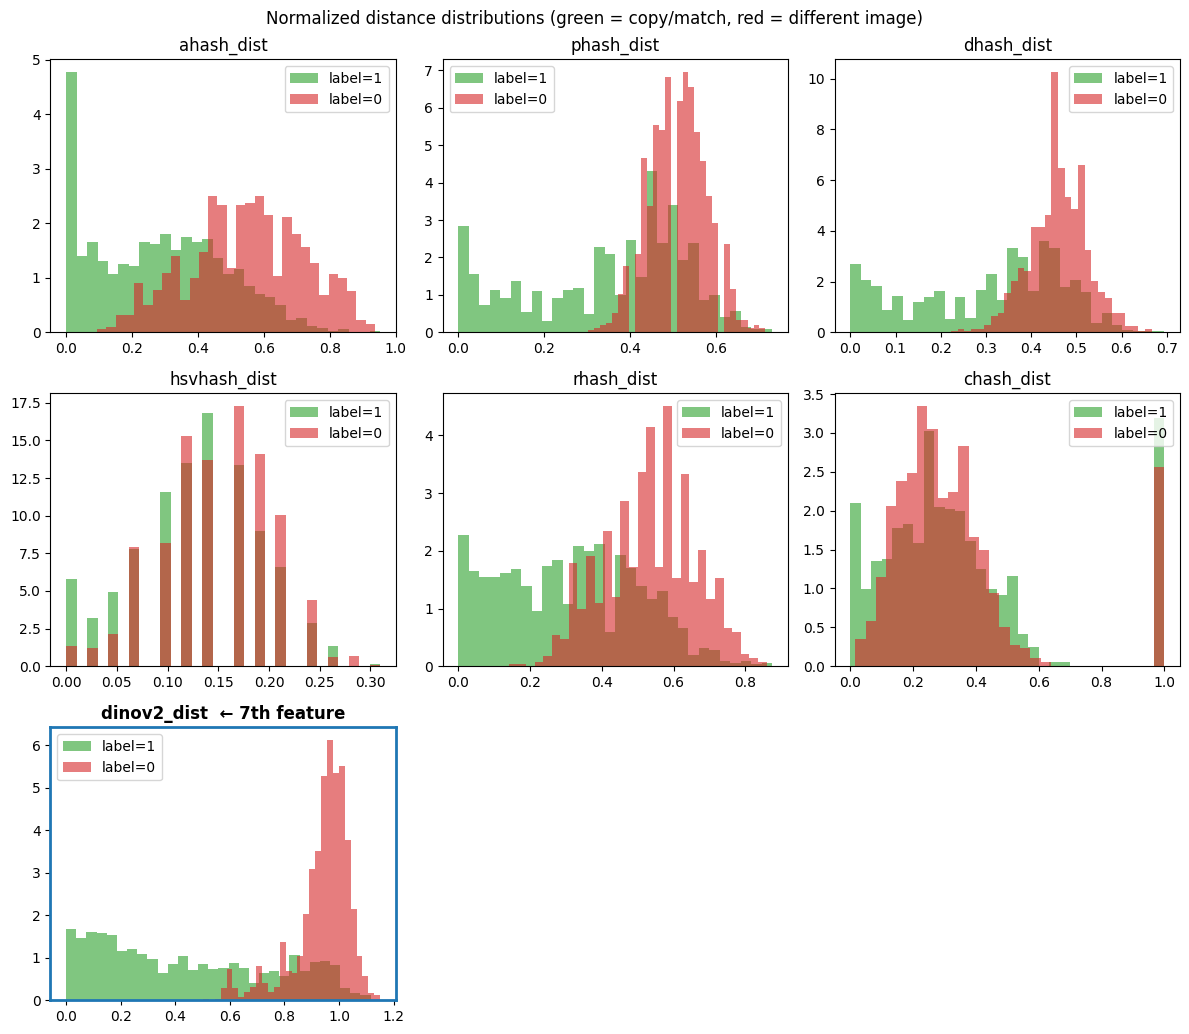

In [5]:
# Feature distributions by class — sanity check that positives/negatives separate.
# The dinov2_dist panel is the one to read closely: it is the only feature whose two
# class histograms barely overlap, which is the whole reason for adding it.
ncols = 3
nrows = int(np.ceil(len(FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharey=False)
axes = np.atleast_1d(axes).ravel()
for ax, feat in zip(axes, FEATURES):
    for lbl, color in [(1, "tab:green"), (0, "tab:red")]:
        ax.hist(df.loc[df.label == lbl, feat], bins=30, alpha=0.6,
                color=color, label=f"label={lbl}", density=True)
    is_new = feat == EMBED_FEATURE
    ax.set_title(f"{feat}  ← 7th feature" if is_new else feat,
                 fontweight="bold" if is_new else "normal")
    if is_new:                          # make the new panel visually obvious
        for spine in ax.spines.values():
            spine.set(edgecolor="tab:blue", linewidth=2)
    ax.legend()
for ax in axes[len(FEATURES):]:        # hide any unused panels
    ax.set_visible(False)
fig.suptitle("Normalized distance distributions (green = copy/match, red = different image)")
plt.tight_layout()
plt.show()

In [6]:
# Per-feature signal, before any fusion. Distances are negated (-dist) so that
# "higher score = more likely a copy", which makes these AUCs directly comparable
# to the fused model's AUC in section 4.
#
# Computed on the FULL dataset — this is exploratory feature triage, not a held-out
# metric. Do not quote these numbers as model performance.
disc_mask = df["transformation"].str.startswith("disc21")

feat_rows = []
for feat in FEATURES:
    pos_mean = df.loc[df.label == 1, feat].mean()
    neg_mean = df.loc[df.label == 0, feat].mean()
    feat_rows.append({
        "feature": feat,
        "mean(copy)": pos_mean,
        "mean(diff)": neg_mean,
        "gap": neg_mean - pos_mean,
        "AUC alone": roc_auc_score(df["label"], -df[feat]),
        "AUC alone (disc21 only)": roc_auc_score(df.loc[disc_mask, "label"],
                                                 -df.loc[disc_mask, feat]),
    })

single_feature_df = (pd.DataFrame(feat_rows)
                       .sort_values("AUC alone", ascending=False)
                       .reset_index(drop=True))
display(single_feature_df)

best_hash = single_feature_df.query("feature != @EMBED_FEATURE").iloc[0]
new_feat = single_feature_df.query("feature == @EMBED_FEATURE").iloc[0]
print(f"Best single hash : {best_hash['feature']}  AUC {best_hash['AUC alone']:.4f} "
      f"(disc21 {best_hash['AUC alone (disc21 only)']:.4f})")
print(f"7th feature      : {new_feat['feature']}  AUC {new_feat['AUC alone']:.4f} "
      f"(disc21 {new_feat['AUC alone (disc21 only)']:.4f})")
print("\nchash_dist / hsvhash_dist sit near 0.5 = near-chance on their own; the fused\n"
      "model can still use them for the classical-augmentation rows, but the DISC21\n"
      "signal is carried by ahash/rhash and now mostly by dinov2_dist.")

,feature,mean(copy),mean(diff),gap,AUC alone,AUC alone (disc21 only)
0,dinov2_dist,0.4412,0.9392,0.4981,0.9193,0.9355
1,ahash_dist,0.2845,0.5475,0.2631,0.8327,0.8423
2,rhash_dist,0.3094,0.5322,0.2228,0.8226,0.8201
3,dhash_dist,0.3015,0.4605,0.1590,0.8024,0.7840
4,phash_dist,0.3498,0.5104,0.1607,0.7798,0.7691
5,hsvhash_dist,0.1281,0.1485,0.0204,0.5936,0.5581
6,chash_dist,0.3404,0.3328,-0.0076,0.5036,0.4733


Best single hash : ahash_dist  AUC 0.8327 (disc21 0.8423)
7th feature      : dinov2_dist  AUC 0.9193 (disc21 0.9355)

chash_dist / hsvhash_dist sit near 0.5 = near-chance on their own; the fused
model can still use them for the classical-augmentation rows, but the DISC21
signal is carried by ahash/rhash and now mostly by dinov2_dist.


## 2. Stratified 80/20 train–test split

We hold out **20%** of the pairs as a test set, stratifying on `label` so the positive rate is preserved in both splits. The model is trained on the 80% split and every reported metric below is computed on the **untouched** 20% test set.

> Earlier versions of this notebook used `GroupKFold` on the source image to prevent augmented variants of the same seed image from leaking across folds. With the dataset now dominated by DISC21 query↔reference pairs (each a distinct image pair), we switch to a simple stratified hold-out for a clean, fast baseline. If you later want to measure generalization to *unseen source images* specifically, reintroduce grouped splitting on a derived `group` key.

In [7]:
X = df[FEATURES].to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index.to_numpy(),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train)} pairs  (positive rate = {y_train.mean():.2%})")
print(f"Test : {len(X_test)} pairs  (positive rate = {y_test.mean():.2%})")

Train: 1778 pairs  (positive rate = 48.71%)
Test : 445 pairs  (positive rate = 48.76%)


## 3. Metric helpers

- **ROC-AUC** — primary, threshold-free ranking quality
- **PR-AUC (average precision)** — more informative under class imbalance
- **Recall @ 95% Precision** — the deployment-relevant number: *how many copymints do we catch if we only allow 5% false flags?*

In [8]:
def recall_at_precision(y_true, y_score, min_precision=0.95):
    """Max recall achievable while keeping precision >= min_precision.
    Returns (recall, threshold). (0.0, None) if precision target is unreachable."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    # precision/recall have len = len(thresholds)+1; drop the last point (no threshold)
    mask = precision[:-1] >= min_precision
    if not mask.any():
        return 0.0, None
    idxs = np.where(mask)[0]
    best = idxs[np.argmax(recall[idxs])]
    return recall[best], thresholds[best]


def make_model():
    """Standardize features, then L2-regularized logistic regression.
    class_weight='balanced' compensates for the negative-heavy label distribution."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000,
                                   class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ])

## 4. Train on 80%, evaluate on the held-out 20%

Fit the pipeline on the training split, then score the test split. This is the **7-feature** model (6 hashes + `dinov2_dist`); §4b compares it against the hashes-only baseline. All metrics below are on the test set the model never saw during fitting.

In [9]:
model = make_model()
model.fit(X_train, y_train)

test_scores = model.predict_proba(X_test)[:, 1]

print("=== Held-out test metrics (20%) ===")
print(f"ROC-AUC : {roc_auc_score(y_test, test_scores):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, test_scores):.4f}")

r95, thr95 = recall_at_precision(y_test, test_scores, min_precision=0.95)
print(f"Recall @ 95% Precision : {r95:.4f}  (score threshold ~ {thr95:.4f})" if thr95 is not None
      else "95% precision not reachable")

y_pred_05 = (test_scores >= 0.5).astype(int)
print(f"F1 @ threshold 0.5     : {f1_score(y_test, y_pred_05):.4f}")

=== Held-out test metrics (20%) ===
ROC-AUC : 0.9497
PR-AUC  : 0.9606
Recall @ 95% Precision : 0.8249  (score threshold ~ 0.5471)
F1 @ threshold 0.5     : 0.8846


In [10]:
# === Held-out test metrics by category ===
# The full-set numbers above are dominated by the easy classical augmentations
# (which score ~0.999), masking performance on the AI-inpainting pairs. Break the
# same three metrics out by category. Reuses test_scores, y_test and the
# recall_at_precision helper. NOTE: test_df is built later in section 5, so we
# assemble an equivalent per-row view from idx_test here to keep run order valid.
INPAINTING_TFS = ["disc21", "disc21_neg"]

eval_df = df.loc[idx_test].copy()
eval_df["score"] = test_scores
eval_df["y"] = y_test
inpaint_mask = eval_df["transformation"].isin(INPAINTING_TFS).to_numpy()


def report_metrics(name, y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())
    print(f"--- {name} ---")
    print(f"positives = {n_pos}   negatives = {n_neg}   total = {len(y_true)}")
    if n_pos == 0 or n_neg == 0:
        print("only one class present -> ROC-AUC / PR-AUC / Recall@P95 skipped\n")
        return
    print(f"ROC-AUC : {roc_auc_score(y_true, y_score):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_true, y_score):.4f}")
    r95, thr95 = recall_at_precision(y_true, y_score, min_precision=0.95)
    if thr95 is not None:
        print(f"Recall @ 95% Precision : {r95:.4f}  (score threshold ~ {thr95:.4f})")
    else:
        print("Recall @ 95% Precision : 95% precision not reachable")
    print()


print("=== Held-out test metrics by category ===\n")
report_metrics("Overall (all test rows)", y_test, test_scores)
report_metrics(
    "Inpainting only (disc21 / disc21_neg)",
    eval_df.loc[inpaint_mask, "y"], eval_df.loc[inpaint_mask, "score"],
)
report_metrics(
    "Classical augmentation only (all other rows)",
    eval_df.loc[~inpaint_mask, "y"], eval_df.loc[~inpaint_mask, "score"],
)

=== Held-out test metrics by category ===

--- Overall (all test rows) ---
positives = 217   negatives = 228   total = 445
ROC-AUC : 0.9497
PR-AUC  : 0.9606
Recall @ 95% Precision : 0.8249  (score threshold ~ 0.5471)

--- Inpainting only (disc21 / disc21_neg) ---
positives = 206   negatives = 211   total = 417
ROC-AUC : 0.9568
PR-AUC  : 0.9675
Recall @ 95% Precision : 0.8641  (score threshold ~ 0.3951)

--- Classical augmentation only (all other rows) ---
positives = 11   negatives = 17   total = 28
ROC-AUC : 1.0000
PR-AUC  : 1.0000
Recall @ 95% Precision : 1.0000  (score threshold ~ 0.9877)



## 4b. Ablation — what does the seventh feature actually buy?

The numbers above are for the 7-feature model, but on their own they don't say whether `dinov2_dist` earned its place. This section refits the **same pipeline on the same 80/20 split**, changing *only* the feature set:

| model | features |
|---|---|
| `hashes only (6)` | the six hash distances — reproduces the previous baseline |
| `hashes + dinov2 (7)` | the model this notebook now ships |
| `dinov2 only (1)` | the new feature alone — is the fusion doing anything, or is DINOv2 carrying it? |

Every metric is on the **held-out 20%**, reported overall and restricted to the hard `disc21`/`disc21_neg` rows where the hashes are known to collapse. Because the split, scaler, solver and seed are identical across the three rows, the difference is attributable to the feature set and nothing else.

Depends on `inpaint_mask`, `X_train`/`X_test` and `recall_at_precision` from the cells above — run this notebook top to bottom.

In [11]:
HASHES_ONLY = "hashes only (6)"
HASHES_PLUS = f"hashes + {EMBED_FEATURE} (7)"
EMBED_ONLY = f"{EMBED_FEATURE} only (1)"

ABLATIONS = {
    HASHES_ONLY: HASH_FEATURES,
    HASHES_PLUS: FEATURES,
    EMBED_ONLY: [EMBED_FEATURE],
}

# X_train/X_test hold columns in FEATURES order; slice rather than re-split so every
# variant sees byte-identical train and test rows.
col_idx = {f: i for i, f in enumerate(FEATURES)}

ablation_rows = []
ablation_models = {}
ablation_scores = {}

for name, feats in ABLATIONS.items():
    cols = [col_idx[f] for f in feats]
    m = make_model().fit(X_train[:, cols], y_train)
    s = m.predict_proba(X_test[:, cols])[:, 1]
    ablation_models[name] = m
    ablation_scores[name] = s

    row = {
        "model": name,
        "n_feat": len(feats),
        "ROC-AUC": roc_auc_score(y_test, s),
        "PR-AUC": average_precision_score(y_test, s),
        "R@P95": recall_at_precision(y_test, s, 0.95)[0],
        "F1@0.5": f1_score(y_test, (s >= 0.5).astype(int)),
        # Same metrics on the hard subset only — an aggregate can look healthy while
        # the DISC21 rows sit at chance.
        "ROC-AUC disc21": roc_auc_score(y_test[inpaint_mask], s[inpaint_mask]),
        "PR-AUC disc21": average_precision_score(y_test[inpaint_mask], s[inpaint_mask]),
        "R@P95 disc21": recall_at_precision(y_test[inpaint_mask], s[inpaint_mask], 0.95)[0],
    }
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows).set_index("model")
display(ablation_df)

base, new = ablation_df.loc[HASHES_ONLY], ablation_df.loc[HASHES_PLUS]
solo = ablation_df.loc[EMBED_ONLY]

print(f"Lift from the 7th feature  ({HASHES_ONLY} -> {HASHES_PLUS}, held-out test)")
print("-" * 68)
for k in ["ROC-AUC", "PR-AUC", "R@P95", "ROC-AUC disc21", "PR-AUC disc21", "R@P95 disc21"]:
    print(f"  {k:<16} {base[k]:.4f} -> {new[k]:.4f}   ({new[k] - base[k]:+.4f})")

print(f"\nFusion check: does adding the 6 hashes beat {EMBED_FEATURE} alone?")
for k in ["ROC-AUC", "R@P95", "ROC-AUC disc21", "R@P95 disc21"]:
    delta = new[k] - solo[k]
    verdict = "fusion helps" if delta > 0.005 else ("no better than solo" if delta > -0.005
                                                    else "fusion HURTS")
    print(f"  {k:<16} solo {solo[k]:.4f} vs fused {new[k]:.4f}   ({delta:+.4f})  {verdict}")

print("\nRead the R@P95 column first — it is the deployment number (how many copymints\n"
      "we catch while false-flagging at most 5% of legitimate mints). Remember the\n"
      "single-reference negative leak flagged at the top: it inflates the DINOv2 rows\n"
      "more than the hash-only row, so this lift is an upper bound.")

,n_feat,ROC-AUC,PR-AUC,R@P95,F1@0.5,ROC-AUC disc21,PR-AUC disc21,R@P95 disc21
model,,,,,,,,
hashes only (6),6,0.8524,0.8786,0.5576,0.7382,0.8487,0.8766,0.5340
hashes + dinov2_dist (7),7,0.9497,0.9606,0.8249,0.8846,0.9568,0.9675,0.8641
dinov2_dist only (1),1,0.9389,0.9502,0.7512,0.8600,0.9502,0.9616,0.8350


Lift from the 7th feature  (hashes only (6) -> hashes + dinov2_dist (7), held-out test)
--------------------------------------------------------------------
  ROC-AUC          0.8524 -> 0.9497   (+0.0973)
  PR-AUC           0.8786 -> 0.9606   (+0.0820)
  R@P95            0.5576 -> 0.8249   (+0.2673)
  ROC-AUC disc21   0.8487 -> 0.9568   (+0.1082)
  PR-AUC disc21    0.8766 -> 0.9675   (+0.0908)
  R@P95 disc21     0.5340 -> 0.8641   (+0.3301)

Fusion check: does adding the 6 hashes beat dinov2_dist alone?
  ROC-AUC          solo 0.9389 vs fused 0.9497   (+0.0107)  fusion helps
  R@P95            solo 0.7512 vs fused 0.8249   (+0.0737)  fusion helps
  ROC-AUC disc21   solo 0.9502 vs fused 0.9568   (+0.0066)  fusion helps
  R@P95 disc21     solo 0.8350 vs fused 0.8641   (+0.0291)  fusion helps

Read the R@P95 column first — it is the deployment number (how many copymints
we catch while false-flagging at most 5% of legitimate mints). Remember the
single-reference negative leak flagged at th

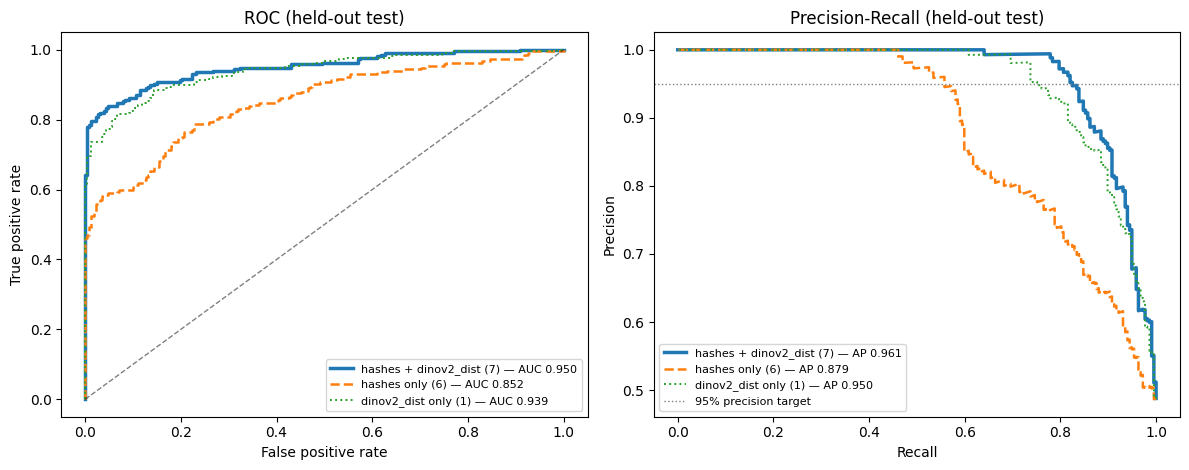

In [12]:
# ROC and Precision-Recall curves on the held-out test set.
# All three ablation variants are overlaid so the gap the 7th feature opens up is
# visible as a curve, not just a table row.
CURVE_STYLES = {
    HASHES_PLUS:  dict(color="tab:blue",  lw=2.5, ls="-"),
    HASHES_ONLY:  dict(color="tab:orange", lw=1.8, ls="--"),
    EMBED_ONLY:   dict(color="tab:green", lw=1.4, ls=":"),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

for name, style in CURVE_STYLES.items():
    s = ablation_scores[name]
    fpr, tpr, _ = roc_curve(y_test, s)
    prec, rec, _ = precision_recall_curve(y_test, s)
    ax1.plot(fpr, tpr, label=f"{name} — AUC {roc_auc_score(y_test, s):.3f}", **style)
    ax2.plot(rec, prec, label=f"{name} — AP {average_precision_score(y_test, s):.3f}", **style)

ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax1.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (held-out test)")
ax1.legend(fontsize=8, loc="lower right")

ax2.axhline(0.95, color="gray", ls=":", lw=1, label="95% precision target")
ax2.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (held-out test)")
ax2.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

# `test_scores` (the 7-feature model from section 4) stays the reference score used by
# every section below — assert the ablation refit reproduces it so the two cannot drift.
assert np.allclose(test_scores, ablation_scores[HASHES_PLUS]), \
    "7-feature ablation refit disagrees with the section-4 model — check FEATURES order"

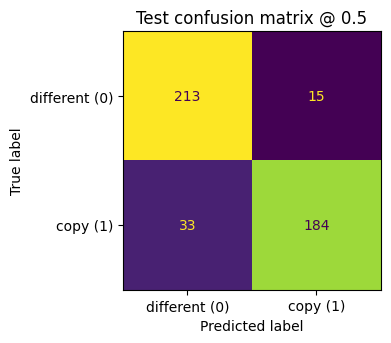

              precision    recall  f1-score   support

   different      0.866     0.934     0.899       228
        copy      0.925     0.848     0.885       217

    accuracy                          0.892       445
   macro avg      0.895     0.891     0.892       445
weighted avg      0.895     0.892     0.892       445



In [13]:
# Confusion matrix + classification report at threshold 0.5 (test set)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_05),
                       display_labels=["different (0)", "copy (1)"]).plot(ax=ax, colorbar=False)
ax.set_title("Test confusion matrix @ 0.5")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_05, target_names=["different", "copy"], digits=3))

## 5. Error analysis by transformation

Which attack / match types does the model handle well, and where does it break? Mean test-set score per transformation — for `label=1` rows, **higher is better**; for negative types (`cross_image`, `disc21_neg`), **lower is better**.

The table carries both scores: `score` (7-feature) and `score_6` (hashes only), plus their difference, so you can see **per transformation** where the seventh feature helps — and whether it hurts anywhere. `cropped_*` and `disc21` were the known weak spots for the hash-only model; those are the rows to check first.

This is computed on the **held-out test rows only**, so it reflects genuine generalization per transformation (some rare transformations may have very few test rows — check the `count` column).

In [14]:
test_df = df.loc[idx_test].copy()
test_df["score"] = test_scores                          # 7-feature model
test_df["score_6"] = ablation_scores[HASHES_ONLY]       # hashes-only, same split

by_tf = (test_df.groupby(["transformation", "label"])
           .agg(mean=("score", "mean"),
                min=("score", "min"),
                max=("score", "max"),
                mean_6=("score_6", "mean"),
                count=("score", "size"))
           .reset_index())

# For positives a higher score is better; for negatives a lower score is better, so
# orient the delta as "improvement" in both directions rather than raw difference.
by_tf["delta"] = np.where(by_tf["label"] == 1,
                          by_tf["mean"] - by_tf["mean_6"],
                          by_tf["mean_6"] - by_tf["mean"])
by_tf = by_tf.sort_values(["label", "mean"])
display(by_tf)

worse = by_tf[by_tf["delta"] < -0.01]
if len(worse):
    print("Transformations where the 7-feature model is WORSE than hashes-only "
          "(delta < -0.01, sign-corrected so negative = regression):")
    display(worse[["transformation", "label", "mean_6", "mean", "delta", "count"]])
else:
    print("No transformation regressed by more than 0.01 when the 7th feature was added.")

,transformation,label,mean,min,max,mean_6,count,delta
6,disc21_neg,0,0.1421,0.0120,0.9393,0.2714,211,0.1293
3,cross_image,0,0.5066,0.2570,0.6843,0.3520,17,-0.1546
5,disc21,1,0.8181,0.0361,1.0000,0.6674,206,0.1507
2,cropped_30%,1,0.9877,0.9877,0.9877,0.7348,1,0.2529
1,cropped_20%,1,0.9948,0.9948,0.9948,0.8117,1,0.1830
8,grid_dropout_20%,1,0.9997,0.9997,0.9997,0.9584,1,0.0412
0,altered_20%,1,1.0000,1.0000,1.0000,0.9989,1,0.0011
4,darkened_0.5x,1,1.0000,1.0000,1.0000,0.9988,2,0.0012
7,edge_filter,1,1.0000,1.0000,1.0000,0.9988,1,0.0012
11,resized_50%,1,1.0000,1.0000,1.0000,0.9989,1,0.0011


Transformations where the 7-feature model is WORSE than hashes-only (delta < -0.01, sign-corrected so negative = regression):


,transformation,label,mean_6,mean,delta,count
3,cross_image,0,0.3520,0.5066,-0.1546,17


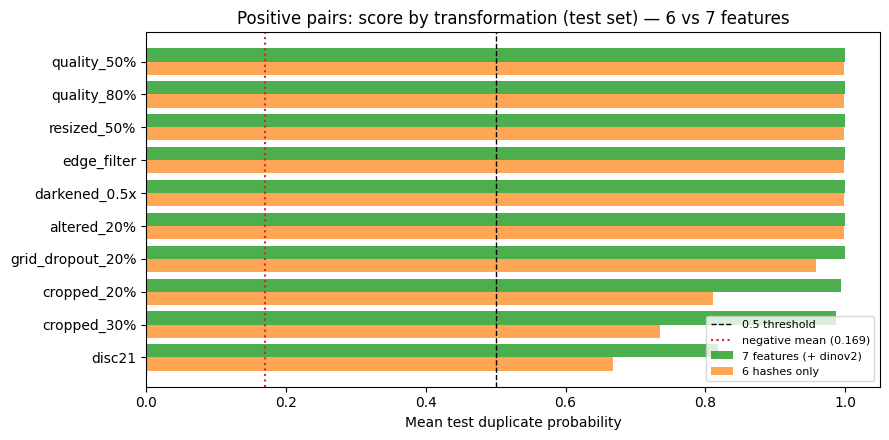

Lowest-scoring TRUE COPIES (missed-detection risk):


,image_b,transformation,score,score_6,dinov2_dist
689,queries/Q49418.jpg,disc21,0.0361,0.0683,0.9522
1047,queries/Q85543.jpg,disc21,0.0627,0.1114,0.9378
685,queries/Q49112.jpg,disc21,0.0887,0.2008,0.9415
195,queries/Q03053.jpg,disc21,0.0901,0.1343,0.9329
562,queries/Q37489.jpg,disc21,0.0919,0.1541,0.9402
1163,queries/Q96891.jpg,disc21,0.1015,0.2012,0.9599
824,queries/Q63053.jpg,disc21,0.1022,0.1044,0.8813
197,queries/Q03218.jpg,disc21,0.1029,0.4669,1.0885


Highest-scoring NON-COPIES (false-flag risk):


,image_a,image_b,transformation,score,score_6,dinov2_dist
2125,references/R038409.jpg,queries/Q05306.jpg,disc21_neg,0.9393,0.6705,0.5014
149,images/beach.jpg,images_variants/golden_bridge/covered.png,cross_image,0.6843,0.7255,0.7904
118,images/beach.jpg,images_variants/dragon-bridge/resized_up.png,cross_image,0.6609,0.2163,0.5906
141,images/golden_bridge.webp,images_variants/beach/cropped10.png,cross_image,0.6208,0.6401,0.7882
94,images/dragon-bridge.png,images_variants/beach/covered.png,cross_image,0.5894,0.1758,0.5925
152,images/beach.jpg,images_variants/golden_bridge/brightened.png,cross_image,0.5723,0.6023,0.7832
139,images/golden_bridge.webp,images_variants/beach/filtered.png,cross_image,0.5570,0.5901,0.7895
2213,references/R038409.jpg,queries/Q28945.jpg,disc21_neg,0.5510,0.5032,0.8412


At threshold 0.5, adding dinov2_dist changed these test rows:
  true copies rescued (miss -> catch) : 40
  true copies broken  (catch -> miss) : 4
  false flags removed                 : 26
  false flags introduced              : 5

Rescued positives (sample):


,image_b,transformation,score,score_6,dinov2_dist
753,queries/Q56888.jpg,disc21,0.9950,0.3931,0.0919
347,queries/Q16114.jpg,disc21,0.9945,0.4863,0.1594
237,queries/Q06786.jpg,disc21,0.9939,0.4617,0.1545
496,queries/Q31245.jpg,disc21,0.9935,0.2156,0.0842
1128,queries/Q93336.jpg,disc21,0.9906,0.4285,0.1984


In [15]:
pos = by_tf[by_tf.label == 1].sort_values("mean")
fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(pos))))
# NB: not named `y` — that is the label vector, still needed by section 8.
bar_y = np.arange(len(pos))
ax.barh(bar_y + 0.20, pos["mean"], height=0.4, color="tab:green", alpha=0.85,
        label="7 features (+ dinov2)")
ax.barh(bar_y - 0.20, pos["mean_6"], height=0.4, color="tab:orange", alpha=0.7,
        label="6 hashes only")
ax.set_yticks(bar_y, pos["transformation"])
ax.axvline(0.5, color="k", ls="--", lw=1, label="0.5 threshold")
neg_mean = test_df.loc[test_df.label == 0, "score"].mean()
ax.axvline(neg_mean, color="tab:red", ls=":", lw=1.5, label=f"negative mean ({neg_mean:.3f})")
ax.set(xlabel="Mean test duplicate probability",
       title="Positive pairs: score by transformation (test set) — 6 vs 7 features")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# Hardest positives & worst negatives on the test set. dinov2_dist is shown alongside
# the score so you can tell "the 7th feature also failed here" (a genuinely hard pair)
# apart from "the fusion ignored a correct dinov2_dist" (a weighting problem).
hard_cols = ["transformation", "score", "score_6", EMBED_FEATURE]
print("Lowest-scoring TRUE COPIES (missed-detection risk):")
display(test_df[test_df.label == 1].nsmallest(8, "score")[["image_b"] + hard_cols])
print("Highest-scoring NON-COPIES (false-flag risk):")
display(test_df[test_df.label == 0].nlargest(8, "score")[["image_a", "image_b"] + hard_cols])

# Rows the 7th feature rescued vs. broke, relative to the hashes-only model at 0.5.
rescued = test_df[(test_df.label == 1) & (test_df.score_6 < 0.5) & (test_df.score >= 0.5)]
broken = test_df[(test_df.label == 1) & (test_df.score_6 >= 0.5) & (test_df.score < 0.5)]
new_fp = test_df[(test_df.label == 0) & (test_df.score_6 < 0.5) & (test_df.score >= 0.5)]
fixed_fp = test_df[(test_df.label == 0) & (test_df.score_6 >= 0.5) & (test_df.score < 0.5)]
print(f"At threshold 0.5, adding {EMBED_FEATURE} changed these test rows:")
print(f"  true copies rescued (miss -> catch) : {len(rescued)}")
print(f"  true copies broken  (catch -> miss) : {len(broken)}")
print(f"  false flags removed                 : {len(fixed_fp)}")
print(f"  false flags introduced              : {len(new_fp)}")
if len(rescued):
    print("\nRescued positives (sample):")
    display(rescued.nlargest(5, "score")[["image_b"] + hard_cols])

## 6. Coefficient interpretation

Coefficients from the model trained on the 80% split, on **standardized features**, so magnitudes are directly comparable even though `dinov2_dist` has a wider raw range than the hashes: more negative = a larger distance pushes harder toward "not a copy".

The second table puts the 6-feature and 7-feature coefficients side by side. Watch how much weight the hashes **lose** once `dinov2_dist` is available — that shrinkage is the clearest evidence of what the new feature replaced, and which hashes were only ever proxies for "these images look alike".

A hash whose weight collapses to near zero here is a candidate for removal from the serving path (each one costs compute at mint time), but check §5 first: several hashes only matter for the classical-augmentation rows, which are a thin slice of this test set.

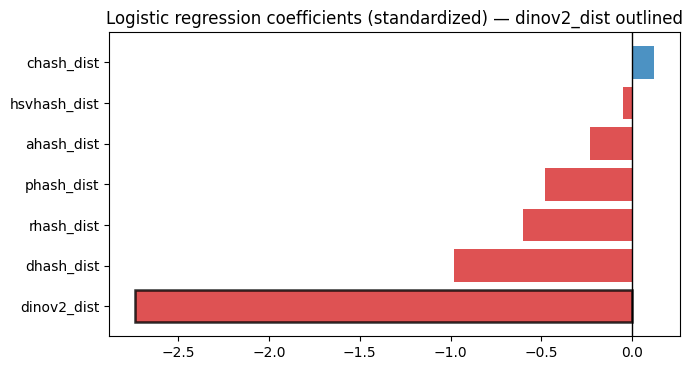

Intercept: 1.3474


,feature,coef (standardized)
6,dinov2_dist,-2.7362
2,dhash_dist,-0.9788
4,rhash_dist,-0.5997
1,phash_dist,-0.4783
0,ahash_dist,-0.2315
3,hsvhash_dist,-0.0475
5,chash_dist,0.1211


,coef (6-feat),coef (7-feat),|coef| change
ahash_dist,-0.6384,-0.2315,-0.4068
rhash_dist,-0.6835,-0.5997,-0.0838
chash_dist,0.1982,0.1211,-0.0771
dhash_dist,-1.0555,-0.9788,-0.0767
phash_dist,-0.4812,-0.4783,-0.0029
hsvhash_dist,-0.0480,-0.0475,-0.0005
dinov2_dist,NaN,-2.7362,NaN


Hash weight lost to dinov2_dist: total |coef| across the 6 hashes went 3.105 -> 2.457; dinov2_dist itself carries 2.736.
Biggest drop: ahash_dist (-0.407).


In [16]:
coef_df = (pd.DataFrame({
    "feature": FEATURES,
    "coef (standardized)": model.named_steps["clf"].coef_[0],
}).sort_values("coef (standardized)"))

fig, ax = plt.subplots(figsize=(7, 3.8))
colors = ["tab:red" if c < 0 else "tab:blue" for c in coef_df["coef (standardized)"]]
bars = ax.barh(coef_df["feature"], coef_df["coef (standardized)"], color=colors, alpha=0.8)
# Outline the 7th feature's bar so it is identifiable at a glance.
for bar, feat in zip(bars, coef_df["feature"]):
    if feat == EMBED_FEATURE:
        bar.set(edgecolor="black", linewidth=1.8)
ax.axvline(0, color="k", lw=1)
ax.set_title(f"Logistic regression coefficients (standardized) — {EMBED_FEATURE} outlined")
plt.tight_layout()
plt.show()

print(f"Intercept: {model.named_steps['clf'].intercept_[0]:.4f}")
display(coef_df)

# --- 6-feature vs 7-feature weights: what did dinov2_dist take over? ---
coef6 = pd.Series(ablation_models[HASHES_ONLY].named_steps["clf"].coef_[0], index=HASH_FEATURES)
coef7 = pd.Series(model.named_steps["clf"].coef_[0], index=FEATURES)

shift_df = pd.DataFrame({
    "coef (6-feat)": coef6.reindex(FEATURES),
    "coef (7-feat)": coef7,
})
shift_df["|coef| change"] = shift_df["coef (7-feat)"].abs() - shift_df["coef (6-feat)"].abs()
display(shift_df.sort_values("|coef| change"))

lost = shift_df["|coef| change"].dropna()
if not lost.empty:
    print(f"Hash weight lost to {EMBED_FEATURE}: total |coef| across the 6 hashes went "
          f"{coef6.abs().sum():.3f} -> {coef7[HASH_FEATURES].abs().sum():.3f}; "
          f"{EMBED_FEATURE} itself carries {abs(coef7[EMBED_FEATURE]):.3f}.")
    print(f"Biggest drop: {lost.idxmin()} ({lost.min():+.3f}).")

## 7. Choosing an operating threshold

For a minting gate, false positives (blocking a legitimate mint) and false negatives (letting a copymint through) have different costs. The table below sweeps thresholds on the **test set**; the **Recall@P95 threshold** from section 4 is the conservative starting point.

In [17]:
rows = []
for thr in np.arange(0.05, 1.0, 0.05):
    pred = (test_scores >= thr).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({"threshold": thr, "precision": precision, "recall": recall,
                 "F1": f1, "flagged": int(tp + fp)})
threshold_table = pd.DataFrame(rows)

# .style needs jinja2 — present in Colab, not necessarily in a bare local venv.
try:
    display(threshold_table.style.highlight_max(subset=["F1"], color="#c8e6c9"))
except (ImportError, AttributeError):
    display(threshold_table)
    print(f"\nBest F1 at threshold {threshold_table.loc[threshold_table.F1.idxmax(), 'threshold']:.2f}")

,threshold,precision,recall,F1,flagged
0,0.050000,0.532020,0.995392,0.693419,406
1,0.100000,0.618076,0.976959,0.757143,343
2,0.150000,0.693603,0.949309,0.801556,297
3,0.200000,0.764045,0.940092,0.842975,267
4,0.250000,0.811475,0.912442,0.859002,244
5,0.300000,0.855263,0.898618,0.876404,228
6,0.350000,0.880734,0.884793,0.882759,218
7,0.400000,0.886792,0.866359,0.876457,212
8,0.450000,0.911330,0.852535,0.880952,203
9,0.500000,0.924623,0.847926,0.884615,199


## 8. Final model & persistence

Refit on **all** data (train + test) — this is the model you'd serialize for the minting gate. Use the threshold chosen above when wiring it into the gate.

⚠️ **This artifact takes 7 features, the deployed one takes 6.** `hashing/api/similarity.py` loads `data/model/copymint_logreg.joblib` and builds its input from `FEATURES_ORDER` (6 hash columns). Dropping a 7-feature model in without updating that list raises at `predict_proba`. To avoid a silent mismatch the file is saved under a **new name** and the feature order is serialized next to the estimator, so the serving side can assert instead of guessing — see the wiring checklist printed by the last cell.

In [ ]:
final_model = make_model()
final_model.fit(X, y)

import joblib

MODEL_FILENAME = "copymint_logreg_7feat.joblib"
BARE_FILENAME = "copymint_logreg_7feat_bare.joblib"

# Save the feature order WITH the estimator. A bare pipeline carries no record of
# which column meant what, and a 7-feature model fed 6 columns (or the same 7 in a
# different order) fails silently-but-wrongly rather than loudly.
joblib.dump({"model": final_model, "features": FEATURES, "version": "7feat-dinov2"},
            MODEL_FILENAME)
print(f"Saved -> {MODEL_FILENAME}   (features: {FEATURES})")

# Also emit a bare-pipeline copy for drop-in compatibility with the current loader,
# which does joblib.load(...).predict_proba(...) directly.
joblib.dump(final_model, BARE_FILENAME)
print(f"Saved -> {BARE_FILENAME}   (bare pipeline, no metadata)")

# Inference example (drawn from the held-out test set)
example = test_df.sample(1, random_state=RANDOM_STATE)
p = final_model.predict_proba(example[FEATURES].to_numpy())[0, 1]
print(f"\n{example.iloc[0]['image_a']}  vs  {example.iloc[0]['image_b']}  [{example.iloc[0]['transformation']}]")
print(f"P(duplicate) = {p:.4f}   (true label = {example.iloc[0]['label']})")
print(f"{EMBED_FEATURE} for this pair = {example.iloc[0][EMBED_FEATURE]:.4f}")

# Kept ASCII on purpose: this block also gets read from a plain Windows terminal,
# where a cp1252 stdout raises UnicodeEncodeError on box-drawing characters.
print(f"""
--- Serving checklist (hashing/api/similarity.py) ---------------------------
1. Copy {MODEL_FILENAME} (or the _bare copy) to hashing/data/model/ and point
   MODEL_PATH at it. Keep the old copymint_logreg.joblib until step 3 is done --
   the 6-feature model is what production is serving right now.
2. FEATURES_ORDER must become: {FEATURES}
3. compute_features() in utils/hash_utils.py returns only the 6 hash distances,
   so '{EMBED_FEATURE}' will be MISSING and the lookup will KeyError. Two options:
     a) cheap -- /similarity already has the FAISS ann distance for each candidate.
        The HNSW index is METRIC_L2 over unit-norm vectors, so its distance is
        squared L2 = 2*(1 - cos_sim), i.e. {EMBED_FEATURE} = ann_distance / 2.0.
        No second embedding pass needed; verify the halving on a known pair first.
     b) explicit -- embed both images with retriever.embedder.ImageEmbedder and
        compute 1 - dot(va, vb) on the unit vectors, matching this notebook's
        feature exactly. Costs one extra forward pass per candidate.
4. Re-tune the decision threshold: section 7's numbers belong to THIS model. The
   6-feature threshold is not transferable.
""")

### 8b. Get the `.joblib` off the runtime

Colab's filesystem is wiped when the session ends, so the two files above are gone unless you move them. The cell below does both, in this order:

1. **Copy to Drive** (`MyDrive/copymint_models/`) — survives the session, no browser interaction, and Drive is already mounted from §0.
2. **Browser download** — one download prompt per file. Popup blockers sometimes silently drop the second one; if a file doesn't arrive, take it from Drive or from the Colab file browser (📁 in the left sidebar).

Set `DOWNLOAD_TO_BROWSER = False` if you only want the Drive copy. Running this outside Colab is a no-op — it just prints where the files already are.

In [ ]:
import shutil

DOWNLOAD_TO_BROWSER = True
DRIVE_MODEL_DIR = "/content/drive/MyDrive/copymint_models"

ARTIFACTS = [MODEL_FILENAME, BARE_FILENAME]

# Fail loudly if section 8 was skipped, rather than downloading a stale file from an
# earlier run that may have been fit on a different feature set.
for f in ARTIFACTS:
    assert os.path.exists(f), f"{f} not found — run the section 8 cell first"
    print(f"{f}  ({os.path.getsize(f) / 1024:.1f} KB)")

# 1. Drive copy — persists past the session, and is what you pull from on the next run.
if os.path.isdir("/content/drive/MyDrive"):
    os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)
    for f in ARTIFACTS:
        shutil.copy2(f, os.path.join(DRIVE_MODEL_DIR, f))
    print(f"\nCopied to Drive -> {DRIVE_MODEL_DIR}")
else:
    print("\nDrive not mounted — skipping the Drive copy.")

# 2. Browser download.
try:
    from google.colab import files
except ImportError:
    print("\nNot running on Colab — nothing to download. Files are at:")
    for f in ARTIFACTS:
        print(f"  {os.path.abspath(f)}")
else:
    if DOWNLOAD_TO_BROWSER:
        print("\nStarting browser download(s)...")
        for f in ARTIFACTS:
            files.download(f)
    else:
        print("\nDOWNLOAD_TO_BROWSER = False — use the Drive copy above.")

## Next steps

1. **Diversify negatives — now the blocking issue.** 1028 of 1029 `disc21_neg` rows pair against the single reference `R038409`. An embedding feature can memorize "not that one photo" far more sharply than a hash can, so the §4b lift is the number most likely to shrink once negatives come from many distinct references. Rebuild the negative pool, re-run, and compare the ablation table before quoting any of this externally.
2. **Serving parity** — wire `dinov2_dist` into `hashing/api/similarity.py` per the checklist in §8. Until that lands, the deployed gate is still the 6-feature model, so §4b describes a model that is not in production.
3. **Grouped evaluation** — derive a `group` key (base image of `image_a`) and switch to `GroupShuffleSplit`. With an embedding in the feature set this matters more than it did for hashes alone: it is the only split that shows generalization to *unseen source images* rather than to unseen crops of seen ones.
4. **Inpainted positives** — generate inpainted / img2img variants (COCO-Inpaint / SSCD-style) and add them as transformation classes. DINOv2 is expected to hold up where the hashes collapsed; this is the set that tests whether it actually does, or whether it just tracks "same scene".
5. **Prune the hash set** — check §6's coefficient-shift table. `chash_dist` and `hsvhash_dist` are near-chance on their own (§1); if their weights also collapse once `dinov2_dist` is present, dropping them cuts per-mint compute for no measurable accuracy cost. Confirm on the classical-augmentation rows first, where they may be the only signal.
6. **Try a non-linear combiner** — logistic regression can only take a weighted sum of these seven distances. Gradient boosting on the same features would capture interactions such as "high `dinov2_dist` *but* near-zero `phash_dist`" (a recompressed near-identical crop). Worth a single comparison run once the negatives are fixed, not before.